# O Neurônio Artificial: O Perceptron
- Baseado no algoritmo de Frank Rosenblatt (1958) e no modelo matemático de McCulloch-Pitts (1943).
- É um **classificador linear binário**:
  - Classifica dados calculando a soma ponderada: $z = w_1 \cdot x_1 + w_2 \cdot x_2 + w_0$ (onde $w_0$ é o *bias/intercept*).
  - Se $z \ge 0 \rightarrow$ Classe 1; se $z < 0 \rightarrow$ Classe 0.
  - **Condição essencial:** As classes precisam ser **linearmente separáveis** no plano.

  <br>

In [1]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix

# https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Perceptron.html

<br>
<br>

### 1. Carregando o Dataset de Vinhos (`load_wine`)
- Vamos classificar dois tipos de vinho (Classe 0 e Classe 1).
- Para permitir a visualização 2D da reta de decisão, utilizaremos apenas 2 variáveis químicas:
  1. `color_intensity` (Intensidade da cor)
  2. `flavanoids` (Concentração de flavonoides)

In [3]:
from sklearn.datasets import load_wine

X_wine, y_wine = load_wine(return_X_y=True, as_frame=True)

# Selecionamos as Classes 0 e 2 (totalmente separáveis por essas duas métricas)
filtro_classes = y_wine.isin([0, 2])
colunas_selecionadas = ['color_intensity', 'flavanoids']

X = X_wine.loc[filtro_classes, colunas_selecionadas]
y = y_wine.loc[filtro_classes]

# Ajustando o target para 0 e 1 (o Perceptron trabalha de forma binária)
y = (y == 2).astype(int)

#print(X.head(3))

#print(y.head(3))

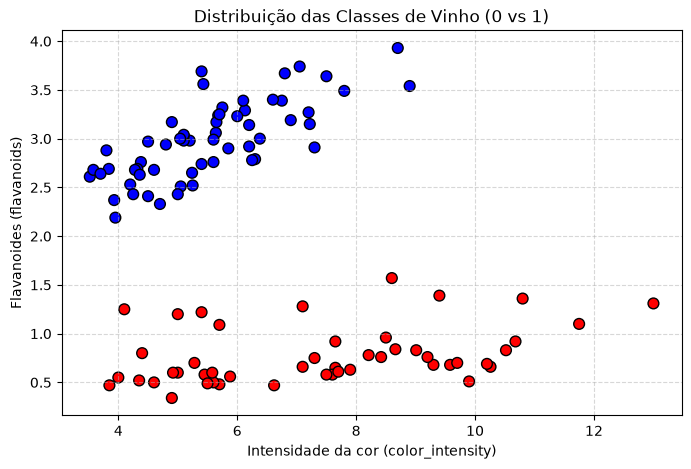

In [4]:
# Gráfico de dispersão para verificar se os dados são linearmente separáveis
fig, ax = plt.subplots(figsize=(8, 5))

scatter = ax.scatter(X['color_intensity'], X['flavanoids'], c=y, cmap='bwr', edgecolors='k', s=60)

ax.set_xlabel('Intensidade da cor (color_intensity)')
ax.set_ylabel('Flavanoides (flavanoids)')
ax.set_title('Distribuição das Classes de Vinho (0 vs 1)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [5]:
# Divisão entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Instanciando e treinando o Perceptron
clf = Perceptron(tol=1e-3, random_state=42, eta0=0.1)
clf.fit(X_train, y_train)

# Avaliação com a Matriz de Confusão
y_pred = clf.predict(X_test)
print("Matriz de Confusão no Conjunto de Teste:")
print(confusion_matrix(y_test, y_pred))

Matriz de Confusão no Conjunto de Teste:
[[19  0]
 [ 0 14]]


In [6]:
# Extraindo os pesos aprendidos (w1, w2) e o viés (w0)
w1 = clf.coef_[0][0]
w2 = clf.coef_[0][1]
w0 = clf.intercept_[0]

print(f"Equação do hiperplano aprendida: ({w1:.3f} * x1) + ({w2:.3f} * x2) + ({w0:.3f}) = 0")

Equação do hiperplano aprendida: (0.811 * x1) + (-2.013 * x2) + (-0.100) = 0


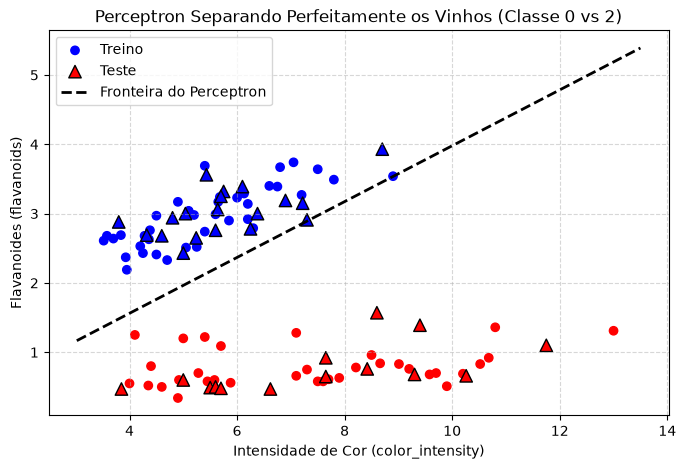

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))

# Plot dos pontos de treino e teste
ax.scatter(X_train['color_intensity'], X_train['flavanoids'], c=y_train, cmap='bwr', marker='o', label='Treino')
ax.scatter(X_test['color_intensity'], X_test['flavanoids'], c=y_test, cmap='bwr', marker='^', edgecolors='k', s=80, label='Teste')

# Gerando a reta de decisão: x2 = (-w1 * x1 - w0) / w2
x_valores = np.linspace(X['color_intensity'].min() - 0.5, X['color_intensity'].max() + 0.5, 100)
y_valores = (-w1 * x_valores - w0) / w2

ax.plot(x_valores, y_valores, color='black', linestyle='--', linewidth=2, label='Fronteira do Perceptron')

ax.set_xlabel('Intensidade de Cor (color_intensity)')
ax.set_ylabel('Flavanoides (flavanoids)')
ax.set_title('Perceptron Separando Perfeitamente os Vinhos (Classe 0 vs 2)')
ax.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

<br>
<br>

---

<br>
<br>


# **2. A Queda Histórica: O Problema do OU Exclusivo (XOR)**
O Perceptron aprende apenas **uma única reta divisora**. Quando os dados são intercalados (não linearmente separáveis), um único neurônio falha completamente.

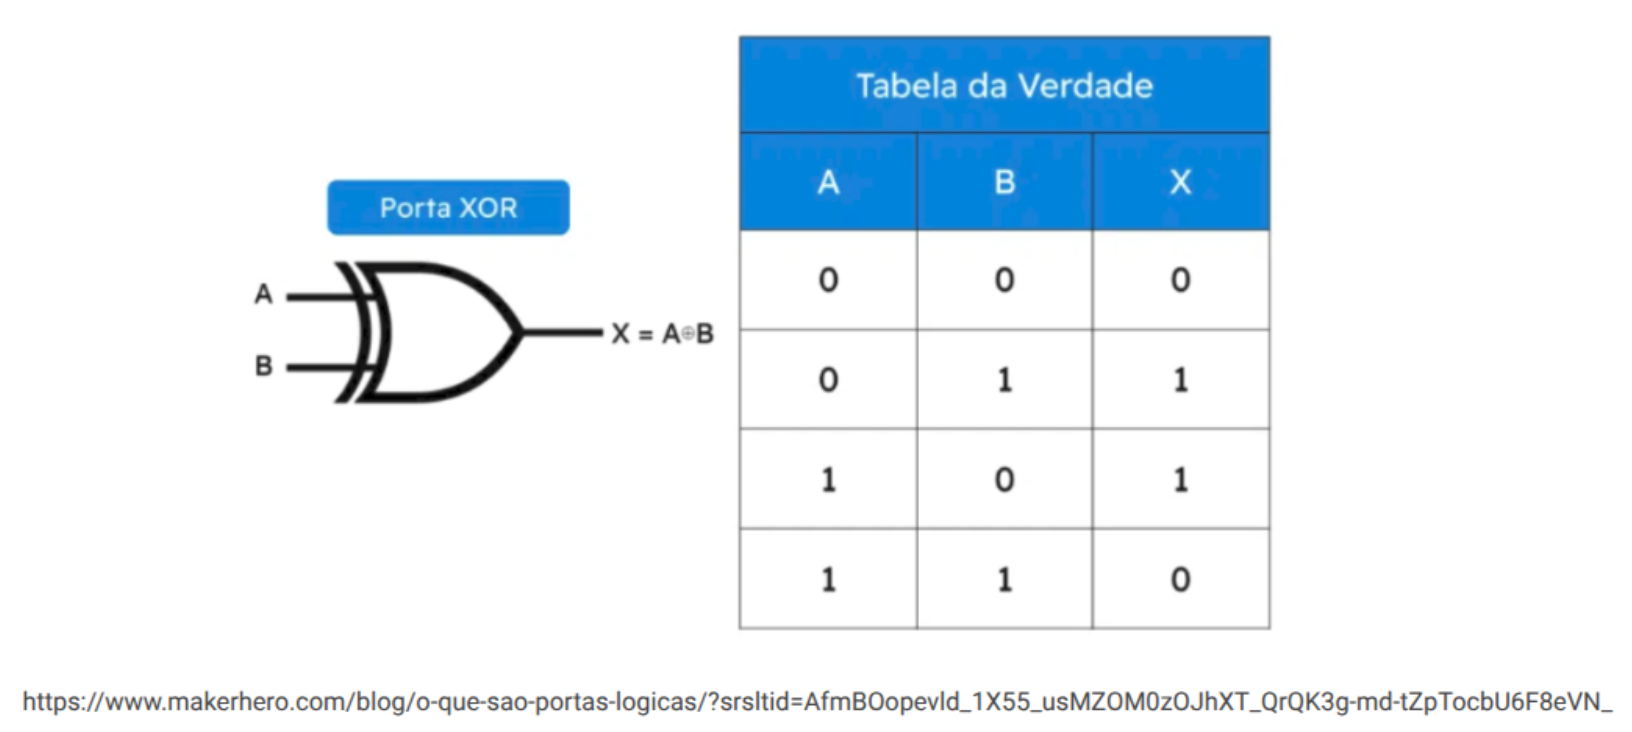

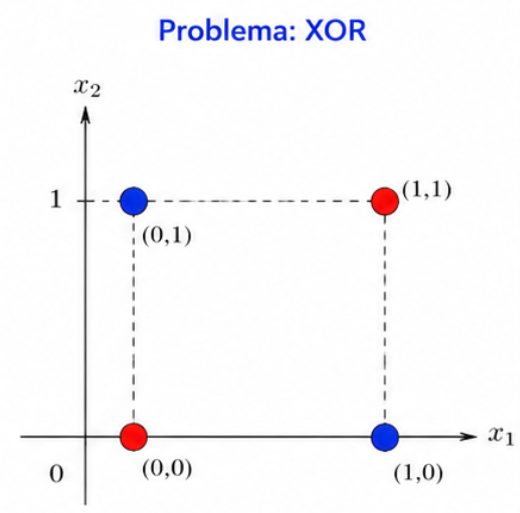

In [8]:
# Tabela verdade do XOR
dados_xor = pd.DataFrame({
    'x1': [0, 0, 1, 1],
    'x2': [0, 1, 0, 1],
    'y':  [0, 1, 1, 0]  # Saídas iguais geram 0, saídas diferentes geram 1
})

X_xor = dados_xor[['x1', 'x2']]
y_xor = dados_xor['y']

# Treinando o Perceptron no XOR
clf_xor = Perceptron(tol=1e-3, random_state=42)
clf_xor.fit(X_xor, y_xor)

print("Previsões do Perceptron para o XOR:", clf_xor.predict(X_xor))
print("Valores Reais esperados:           ", list(y_xor))
print("\nAcurácia do Perceptron no XOR: 50% (equivalente a jogar uma moeda).")

Previsões do Perceptron para o XOR: [0 0 0 0]
Valores Reais esperados:            [0, 1, 1, 0]

Acurácia do Perceptron no XOR: 50% (equivalente a jogar uma moeda).


<br>
<br>

##  Vamos tentar resolver o problema com Tensorflow

<br>

https://www.tensorflow.org/install/pip?hl=pt-br


In [9]:
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

I0000 00:00:1787956118.441514  223888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787956118.475319  223888 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787956119.314296  223888 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
modelo_mlp = Sequential([
    Dense(4, input_dim=2, activation='tanh'), # CAMADA OCULTA + ENTRADA
    Dense(1, activation='sigmoid') # CAMADA DE SAÍDA
])

# Taxa de aprendizado em 0.05 para convergir rápido
modelo_mlp.compile(
    optimizer=Adam(learning_rate=0.05),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 200 época
modelo_mlp.fit(X_xor, y_xor, epochs=200, verbose=0)

W0000 00:00:1787956130.856946  223888 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [11]:
# Uma forma de visualizar a estrutura da rede
# modelo_mlp.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53 (216.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 36 (148.00 B)

* Layer (type): Mostra o nome interno e o tipo da camada (Dense).
* Output Shape (None, 4): O 4 representa os 4 neurônios daquela camada. O None significa que a rede aceita qualquer quantidade de linhas de dados (batch size) de uma vez só.
* Param # (Parâmetros): É a quantidade de conexões matemáticas que a rede vai ter que aprender (pesos + vieses/biases).
* Na primeira camada são 12 parâmetros: (2 entradas × 4 neurônios) + 4 biases.
* Na segunda camada são 5 parâmetros: (4 neurônios anteriores × 1 neurônio de saída) + 1 bias.
* Total de 17 parâmetros que o otimizador Adam vai ajustar durante o treino.



Alternativas: 


1) https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=xor&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4&seed=0.58089&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false
2) https://github.com/paulgavrikov/visualkeras   
3) from tensorflow.keras.utils import plot_model

# Detalhes da implementação

``` python
# Cria um modelo de rede neural sequencial (camada por camada, em pilha)
modelo_mlp = Sequential([
    # Camada Oculta: Cria 4 neurônios conectados a 2 entradas (input_dim=2).
    # A função 'tanh' ativa os neurônios e ajuda a rede a aprender relações
    # não-lineares.
    Dense(4, input_dim=2, activation='tanh'),

    # Camada de Saída: Cria 1 neurônio final para dar a resposta do XOR.
    # A função 'sigmoid' transforma o resultado em um valor entre 0 e 1 (de
    # modo geral a gente usa p/ classificação binária).
    Dense(1, activation='sigmoid')
])

# Taxa de aprendizado em 0.05 para convergir rápido
modelo_mlp.compile(
    # Define o otimizador Adam com uma taxa de aprendizado de 0.05 para ajustar
    # os pesos rapidamente
    optimizer=Adam(learning_rate=0.05),

    # Define a função de perda como entropia cruzada binária, ideal para
    # problemas de sim/não (0 ou 1)
    loss='binary_crossentropy',

    # Define que queremos monitorar a acurácia (porcentagem de acertos) durante o treino
    metrics=['accuracy']
)

# Treina o modelo passando os dados de entrada (X_xor) e os resultados
# esperados (y_xor)
# O modelo vai repetir o processo de ajuste de pesos por 200 épocas (rodadas
# completas)
# O verbose=0 silencia o terminal, ocultando as barras de progresso de cada
# época
modelo_mlp.fit(X_xor, y_xor, epochs=200, verbose=0)
```



# Output

In [12]:
probabilidades = modelo_mlp.predict(X_xor)
predicoes_finais = (probabilidades >= 0.5).astype(int).flatten()

print("Previsões da Rede Neural (MLP):", predicoes_finais)
print("Valores Reais esperados:        ", list(y_xor))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Previsões da Rede Neural (MLP): [0 1 1 0]
Valores Reais esperados:         [0, 1, 1, 0]
